# Klasifikasi Tingkat Keparahan Alzheimer Berbasis Citra MRI

**Anggota:**
1. Ulfia Nurmalizha Ramadhani (064)
2. Luthfiana Syakira Eka Ramadani (071)
3. Sabrina Miftakhul Jana (148)

**Kelas:** 2024E



## Install & Import Library

In [ ]:
!pip install -q kagglehub opencv-python-headless
!pip install tensorflow scikit-image

In [ ]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from skimage.feature import local_binary_pattern, hog

# Set seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Library berhasil diimport!')
print('GPU tersedia :', tf.config.list_physical_devices('GPU'))


Library berhasil diimport!
GPU tersedia : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Download Dataset

In [ ]:
import kagglehub
path = kagglehub.dataset_download('azminur2856/alzheimer-mri-dataset')
print('Dataset path:', path)

Using Colab cache for faster access to the 'alzheimer-mri-dataset' dataset.
Dataset path: /kaggle/input/alzheimer-mri-dataset


## Konfigurasi Global

In [ ]:
RAW_DIR = None
for root, dirs, files in os.walk(path):
    subdirs = [d for d in dirs if os.path.isdir(os.path.join(root, d))]
    if len(subdirs) >= 2 and 'train' not in subdirs and 'test' not in subdirs:
        RAW_DIR = root
        break

for root, dirs, files in os.walk(path):
    if 'train' in dirs and 'test' in dirs:
        RAW_DIR = None
        DATASET_DIR = root
        break

if RAW_DIR is not None:
    from sklearn.model_selection import train_test_split
    import shutil
    DATASET_DIR = '/content/alzheimer_split'
    print(f'Membuat split train/test di {DATASET_DIR} ...')
    for cls in os.listdir(RAW_DIR):
        cls_path = os.path.join(RAW_DIR, cls)
        if not os.path.isdir(cls_path):
            continue
        all_files = [f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        train_files, test_files = train_test_split(
            all_files, test_size=0.2, random_state=SEED)
        for split, flist in [('train', train_files), ('test', test_files)]:
            dest = os.path.join(DATASET_DIR, split, cls)
            os.makedirs(dest, exist_ok=True)
            for fname in flist:
                shutil.copy(os.path.join(cls_path, fname),
                            os.path.join(dest, fname))
        print(f'  {cls}: {len(train_files)} train, {len(test_files)} test')
    print('Split selesai!')

train_path  = os.path.join(DATASET_DIR, 'train')
CLASSES     = sorted([d for d in os.listdir(train_path)
                      if os.path.isdir(os.path.join(train_path, d))])
NUM_CLASSES = len(CLASSES)
print('\nKelas:', CLASSES)

# Parameter utama
IMG_SIZE   = (224, 224)
BATCH_SIZE = 16
EPOCHS_CNN = 50
EPOCHS_TL  = 50
EPOCHS_PRE = 50
LR         = 1e-4
OUTPUT_DIR = '/content/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Dataset dir :', DATASET_DIR)

Membuat split train/test di /content/alzheimer_split ...
  ModerateDemented: 8000 train, 2000 test
  NonDemented: 8000 train, 2000 test
  VeryMildDemented: 8000 train, 2000 test
  MildDemented: 8000 train, 2000 test
Split selesai!

Kelas: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
Dataset dir : /content/alzheimer_split


## Preprocessing Morfologi

In [ ]:
def apply_morphology(img_bgr):
    # Step 1: Grayscale
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    # Step 2: CLAHE (meningkatkan kontras lokal)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    # Step 3: Gaussian Blur (mengurangi noise)
    blurred = cv2.GaussianBlur(enhanced, (5, 5), 0)
    # Step 4: Otsu Thresholding
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # Step 5: Operasi Morfologi
    kernel   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    opened   = cv2.morphologyEx(binary, cv2.MORPH_OPEN,     kernel)
    closed   = cv2.morphologyEx(opened, cv2.MORPH_CLOSE,    kernel)
    gradient = cv2.morphologyEx(closed, cv2.MORPH_GRADIENT, kernel)
    # Step 6: Masking area otak
    masked = cv2.bitwise_and(enhanced, enhanced, mask=closed)
    # Gabungkan 3 channel: masked, gradient, enhanced
    return cv2.merge([masked, gradient, enhanced])

In [ ]:
def load_image(img_path, img_size, use_morph=True):
    img = cv2.imread(img_path)
    img = cv2.resize(img, img_size)
    if use_morph:
        img = apply_morphology(img)
    return img.astype(np.float32) / 255.0

In [ ]:
#Helper: Confusion Matrix
def plot_cm(y_true, y_pred, title):
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'Confusion Matrix — {title} (%)')
    plt.xlabel('Prediksi'); plt.ylabel('Label Asli')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    fname = title.replace(' ', '_').replace('—', '').replace('+', 'plus').strip('_')
    plt.savefig(os.path.join(OUTPUT_DIR, f'cm_{fname}.png'), dpi=150)
    plt.show()

print('plot_cm siap digunakan.')


plot_cm siap digunakan.


## Visualisasi Hasil Morfologi

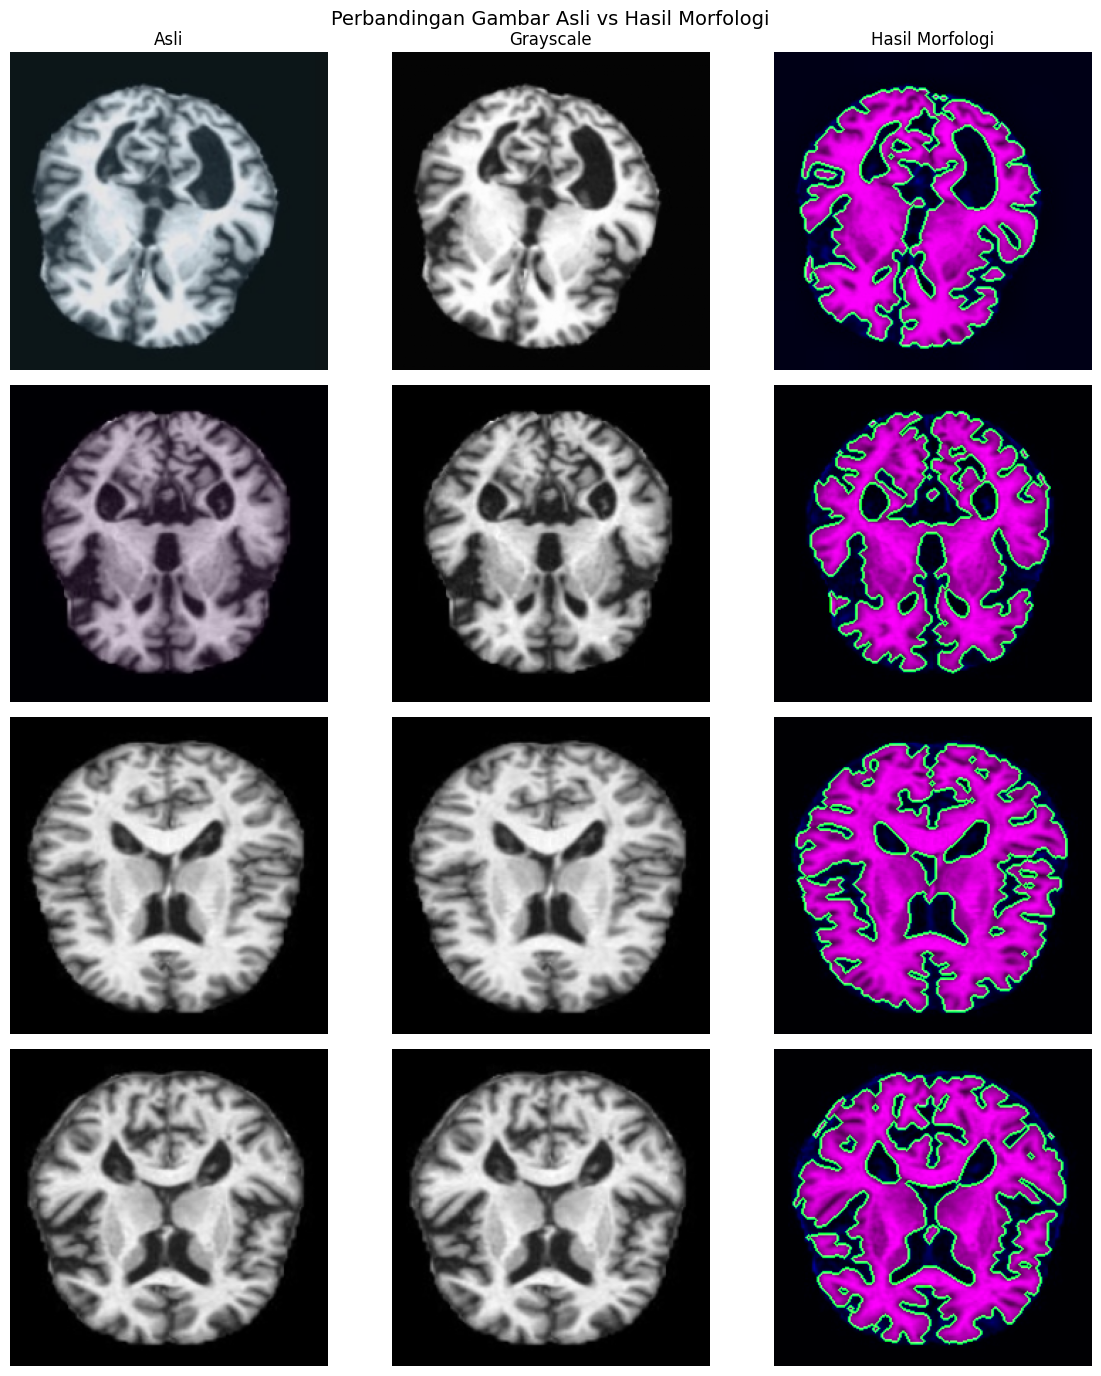

In [ ]:
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(12, 3.5 * NUM_CLASSES))
fig.suptitle('Perbandingan Gambar Asli vs Hasil Morfologi', fontsize=14)

for i, cls in enumerate(CLASSES):
    cls_dir   = os.path.join(DATASET_DIR, 'train', cls)
    img_file  = os.listdir(cls_dir)[0]
    img_path  = os.path.join(cls_dir, img_file)
    img_bgr   = cv2.resize(cv2.imread(img_path), IMG_SIZE)
    img_rgb   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    img_morph = apply_morphology(img_bgr)

    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title('Asli' if i == 0 else '')
    axes[i, 1].imshow(img_gray, cmap='gray')
    axes[i, 1].set_title('Grayscale' if i == 0 else '')
    axes[i, 2].imshow(img_morph)
    axes[i, 2].set_title('Hasil Morfologi' if i == 0 else '')
    for ax in axes[i]:
        ax.axis('off')
    axes[i, 0].set_ylabel(cls, rotation=0, labelpad=90, fontsize=9, va='center')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'visualisasi_morfologi.png'), dpi=150, bbox_inches='tight')
plt.show()

## Load Dataset

In [ ]:
#Generator untuk CNN Baseline & ResNet50
MAX_GEN_SAMPLES = 500  # per kelas

import shutil
GEN_DIR = '/content/alzheimer_subset'
if not os.path.exists(GEN_DIR):
    print(f'Membuat subset {MAX_GEN_SAMPLES}/kelas di {GEN_DIR}...')
    for split in ['train', 'test']:
        for cls in CLASSES:
            src = os.path.join(DATASET_DIR, split, cls)
            dst = os.path.join(GEN_DIR, split, cls)
            os.makedirs(dst, exist_ok=True)
            files = sorted(os.listdir(src))[:MAX_GEN_SAMPLES]
            for f in files:
                shutil.copy(os.path.join(src, f), os.path.join(dst, f))
    print('Subset selesai!')
else:
    print('Subset sudah ada, skip copy.')

# Augmentasi agresif
aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.15
)
plain = ImageDataGenerator(rescale=1./255)

kw = dict(target_size=IMG_SIZE, batch_size=BATCH_SIZE,
          class_mode='categorical', classes=CLASSES, seed=SEED)

train_gen = aug.flow_from_directory(os.path.join(GEN_DIR, 'train'),
                                    subset='training',   **kw)
val_gen   = aug.flow_from_directory(os.path.join(GEN_DIR, 'train'),
                                    subset='validation', **kw)
test_gen  = plain.flow_from_directory(os.path.join(GEN_DIR, 'test'),
                                      shuffle=False, **kw)

#Hitung class_weight
from sklearn.utils.class_weight import compute_class_weight
y_train_gen = train_gen.classes
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train_gen
)
CLASS_WEIGHT = dict(enumerate(class_weights_arr))
print('\nClass weights:')
for i, cls in enumerate(CLASSES):
    print(f'  {cls}: {CLASS_WEIGHT[i]:.3f}')
print('\nGenerator selesai dibuat!')


Membuat subset 500/kelas di /content/alzheimer_subset...
Subset selesai!
Found 1700 images belonging to 4 classes.
Found 300 images belonging to 4 classes.
Found 2000 images belonging to 4 classes.

Class weights:
  MildDemented: 1.000
  ModerateDemented: 1.000
  NonDemented: 1.000
  VeryMildDemented: 1.000

Generator selesai dibuat!


In [ ]:
#Load array numpy untuk Hybrid CNN-SVM
IMG_SIZE_SVM  = (224, 224)
MAX_PER_CLASS = 500

def load_as_array(dataset_dir, img_size, max_per_class=500):
    label_map = {cls: i for i, cls in enumerate(CLASSES)}
    X_train, y_train, X_test, y_test = [], [], [], []
    for split, Xlist, ylist in [('train', X_train, y_train),
                                  ('test',  X_test,  y_test)]:
        for cls in CLASSES:
            folder = os.path.join(dataset_dir, split, cls)
            files  = [f for f in os.listdir(folder)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            files  = files[:max_per_class]
            print(f'  [{split}] {cls}: {len(files)} gambar')
            for fname in files:
                img = load_image(os.path.join(folder, fname), img_size, use_morph=True)
                Xlist.append(img)
                ylist.append(label_map[cls])
    return (np.array(X_train, dtype=np.float32), np.array(y_train, dtype=np.int32),
            np.array(X_test,  dtype=np.float32), np.array(y_test,  dtype=np.int32))

print('Memuat dataset sebagai array...')
X_train, y_train, X_test, y_test = load_as_array(DATASET_DIR, IMG_SIZE_SVM, MAX_PER_CLASS)
print(f'\nTrain shape : {X_train.shape}')
print(f'Test  shape : {X_test.shape}')
est_mb = (X_train.nbytes + X_test.nbytes) / 1024**2
print(f'Estimasi RAM: {est_mb:.1f} MB')


Memuat dataset sebagai array...
  [train] MildDemented: 500 gambar
  [train] ModerateDemented: 500 gambar
  [train] NonDemented: 500 gambar
  [train] VeryMildDemented: 500 gambar
  [test] MildDemented: 500 gambar
  [test] ModerateDemented: 500 gambar
  [test] NonDemented: 500 gambar
  [test] VeryMildDemented: 500 gambar

Train shape : (2000, 224, 224, 3)
Test  shape : (2000, 224, 224, 3)
Estimasi RAM: 2296.9 MB


## Distribusi Kelas

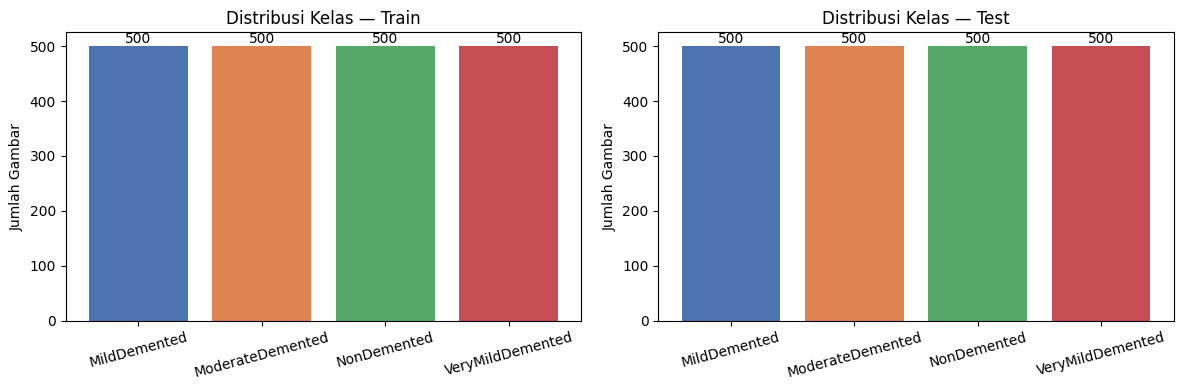

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (y, title) in zip(axes, [(y_train, 'Train'), (y_test, 'Test')]):
    counts = [np.sum(y == i) for i in range(NUM_CLASSES)]
    ax.bar(CLASSES, counts, color=['#4C72B0','#DD8452','#55A868','#C44E52'])
    ax.set_title(f'Distribusi Kelas — {title}')
    ax.set_ylabel('Jumlah Gambar')
    ax.tick_params(axis='x', rotation=15)
    for j, v in enumerate(counts):
        ax.text(j, v + 5, str(v), ha='center')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distribusi_kelas.png'), dpi=150)
plt.show()

---
## Model 1 — LBP + SVM

**Local Binary Pattern (LBP)** adalah deskriptor tekstur klasik yang mendeskripsikan
pola intensitas lokal setiap piksel terhadap tetangganya.
Berperan sebagai baseline *traditional feature extraction* sebelum pendekatan deep learning.


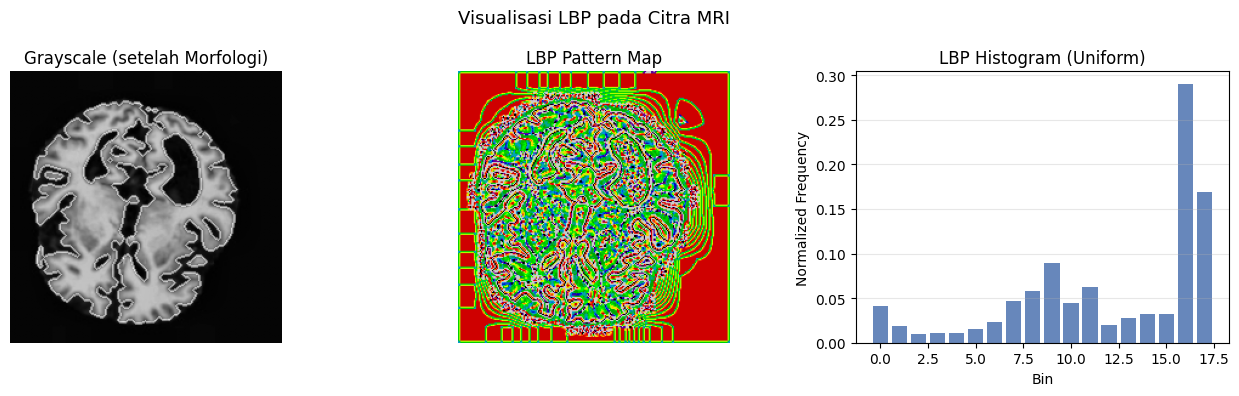

Dimensi fitur LBP per gambar: 18

Mengekstrak fitur LBP — TRAIN...
Mengekstrak fitur LBP — TEST...
Shape train: (2000, 18), test: (2000, 18)
Normalisasi selesai.


In [ ]:
#LBP Feature Extractor
LBP_RADIUS   = 2
LBP_N_POINTS = 8 * LBP_RADIUS
LBP_N_BINS   = LBP_N_POINTS + 2

def extract_lbp_features(img_array):
    gray = np.mean(img_array, axis=2)  # (H, W)
    lbp  = local_binary_pattern(gray, LBP_N_POINTS, LBP_RADIUS, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=LBP_N_BINS,
                            range=(0, LBP_N_BINS), density=True)
    return hist.astype(np.float32)


#Visualisasi LBP pada sampel MRI
sample_path_lbp = os.path.join(DATASET_DIR, 'train', CLASSES[0],
                               os.listdir(os.path.join(DATASET_DIR, 'train', CLASSES[0]))[0])
sample_img_lbp   = cv2.resize(cv2.imread(sample_path_lbp), IMG_SIZE)
sample_morph_lbp = apply_morphology(sample_img_lbp).astype(np.float32) / 255.0
sample_gray_lbp  = np.mean(sample_morph_lbp, axis=2)
lbp_map          = local_binary_pattern(sample_gray_lbp, LBP_N_POINTS, LBP_RADIUS, method='uniform')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Visualisasi LBP pada Citra MRI', fontsize=13)
axes[0].imshow((sample_gray_lbp * 255).astype(np.uint8), cmap='gray')
axes[0].set_title('Grayscale (setelah Morfologi)'); axes[0].axis('off')
axes[1].imshow(lbp_map, cmap='nipy_spectral')
axes[1].set_title('LBP Pattern Map'); axes[1].axis('off')
hist_lbp, _ = np.histogram(lbp_map.ravel(), bins=LBP_N_BINS, range=(0, LBP_N_BINS), density=True)
axes[2].bar(range(LBP_N_BINS), hist_lbp, color='#4C72B0', alpha=0.85)
axes[2].set_title('LBP Histogram (Uniform)')
axes[2].set_xlabel('Bin'); axes[2].set_ylabel('Normalized Frequency')
axes[2].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'visualisasi_lbp.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Dimensi fitur LBP per gambar: {LBP_N_BINS}')

#Ekstraksi fitur LBP untuk seluruh dataset
print('\nMengekstrak fitur LBP — TRAIN...')
feats_lbp_train = np.array([extract_lbp_features(img) for img in X_train], dtype=np.float32)
print('Mengekstrak fitur LBP — TEST...')
feats_lbp_test  = np.array([extract_lbp_features(img) for img in X_test],  dtype=np.float32)
print(f'Shape train: {feats_lbp_train.shape}, test: {feats_lbp_test.shape}')

scaler_lbp             = StandardScaler()
feats_lbp_train_scaled = scaler_lbp.fit_transform(feats_lbp_train)
feats_lbp_test_scaled  = scaler_lbp.transform(feats_lbp_test)
print('Normalisasi selesai.')


In [ ]:
print('Melatih SVM (LBP)...')
svm_lbp = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=SEED)
svm_lbp.fit(feats_lbp_train_scaled, y_train)
print('SVM LBP selesai dilatih!')


Melatih SVM (LBP)...
SVM LBP selesai dilatih!


Model 1 — LBP + SVM (Traditional)
Accuracy : 43.25%
F1-Score : 0.4198

                  precision    recall  f1-score   support

    MildDemented       0.38      0.48      0.42       500
ModerateDemented       0.54      0.65      0.59       500
     NonDemented       0.43      0.39      0.41       500
VeryMildDemented       0.34      0.21      0.26       500

        accuracy                           0.43      2000
       macro avg       0.42      0.43      0.42      2000
    weighted avg       0.42      0.43      0.42      2000



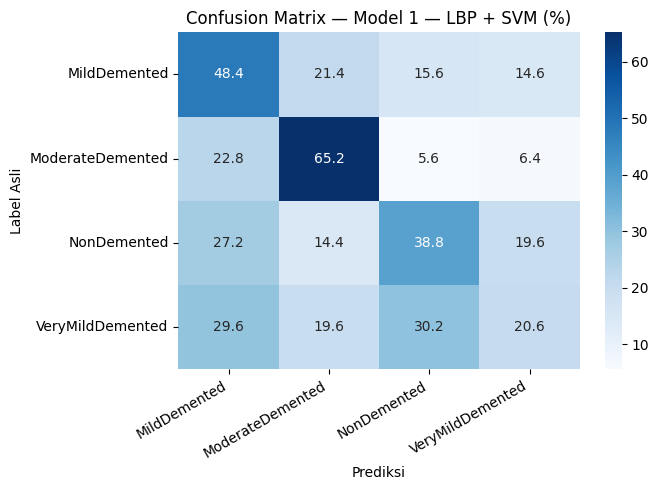

In [ ]:
y_pred_lbp = svm_lbp.predict(feats_lbp_test_scaled)
acc_lbp    = accuracy_score(y_test, y_pred_lbp)
f1_lbp     = f1_score(y_test, y_pred_lbp, average='weighted')

print('Model 1 — LBP + SVM')
print(f'Accuracy : {acc_lbp*100:.2f}%')
print(f'F1-Score : {f1_lbp:.4f}\n')
print(classification_report(y_test, y_pred_lbp, target_names=CLASSES))
plot_cm(y_test, y_pred_lbp, 'Model 1 — LBP + SVM')


---
## Model 2 — CNN Baseline (Deep Learning)
### Bangun Model CNN


In [ ]:
from tensorflow.keras import regularizers

def build_cnn(img_size, num_classes):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, 3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4),
                      input_shape=(*img_size, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.2),
        # Block 2
        layers.Conv2D(64, 3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.2),
        # Block 3
        layers.Conv2D(128, 3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),
        # Classifier
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ], name='CNN_Baseline')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn(IMG_SIZE, NUM_CLASSES)
cnn_model.summary()


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,196 (500.77 KB)

 Trainable params: 127,748 (499.02 KB)

 Non-trainable params: 448 (1.75 KB)

### Training CNN Baseline


Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 45s 325ms/step - accuracy: 0.3035 - loss: 1.4202 - val_accuracy: 0.2467 - val_loss: 1.5492 - learning_rate: 0.0010
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 25s 230ms/step - accuracy: 0.3529 - loss: 1.3313 - val_accuracy: 0.2500 - val_loss: 1.9633 - learning_rate: 0.0010
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 25s 230ms/step - accuracy: 0.3824 - loss: 1.2967 - val_accuracy: 0.2500 - val_loss: 2.3294 - learning_rate: 0.0010
Epoch 4/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 25s 229ms/step - accuracy: 0.3806 - loss: 1.2757 - val_accuracy: 0.2867 - val_loss: 2.3240 - learning_rate: 0.0010
Epoch 5/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 25s 232ms/step - accuracy: 0.4224 - loss: 1.2361 - val_accuracy: 0.2500 - val_loss: 3.3046 - learning_rate: 0.0010
Epoch 6/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 25s 230ms/step - accuracy: 0.4471 - loss: 1.1933 - val_accuracy: 0.2767 - val_loss: 2.4028 - learning_rate: 0.0010
Epoch 7/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 25s 231ms/step - accuracy: 0.4

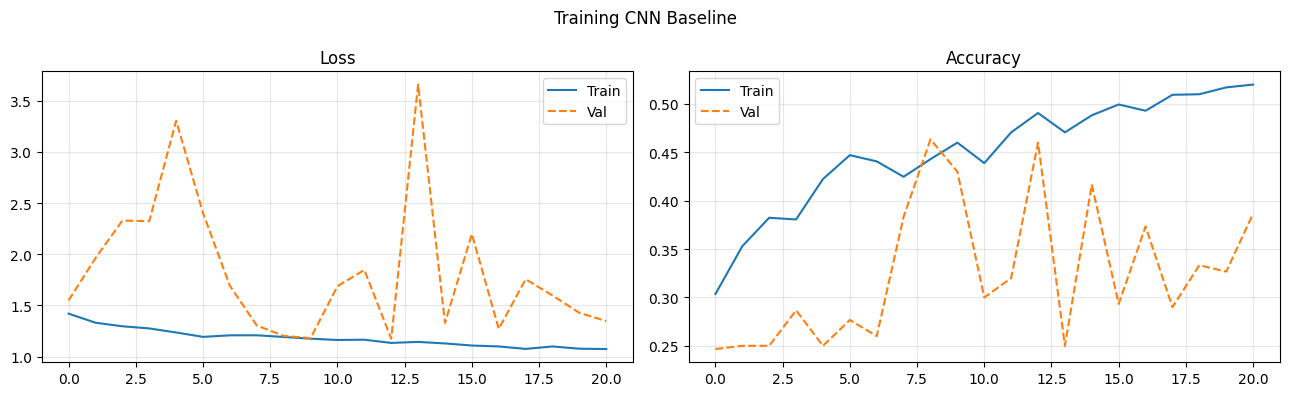

In [ ]:
cbs = [
    EarlyStopping(monitor='val_accuracy', patience=12,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5,
                      patience=6, min_lr=1e-6, verbose=1)
]
history_cnn = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_CNN,
    class_weight=CLASS_WEIGHT,   # <-- fix imbalance
    callbacks=cbs,
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Training CNN Baseline')
axes[0].plot(history_cnn.history['loss'],     label='Train')
axes[0].plot(history_cnn.history['val_loss'], label='Val', linestyle='--')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history_cnn.history['accuracy'],     label='Train')
axes[1].plot(history_cnn.history['val_accuracy'], label='Val', linestyle='--')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'history_cnn.png'), dpi=150)
plt.show()


### Evaluasi CNN Baseline


Model 2 — CNN Baseline
Accuracy : 47.80%
F1-Score : 0.4593

                  precision    recall  f1-score   support

    MildDemented       0.37      0.25      0.30       500
ModerateDemented       0.61      0.67      0.63       500
     NonDemented       0.51      0.71      0.59       500
VeryMildDemented       0.35      0.28      0.31       500

        accuracy                           0.48      2000
       macro avg       0.46      0.48      0.46      2000
    weighted avg       0.46      0.48      0.46      2000



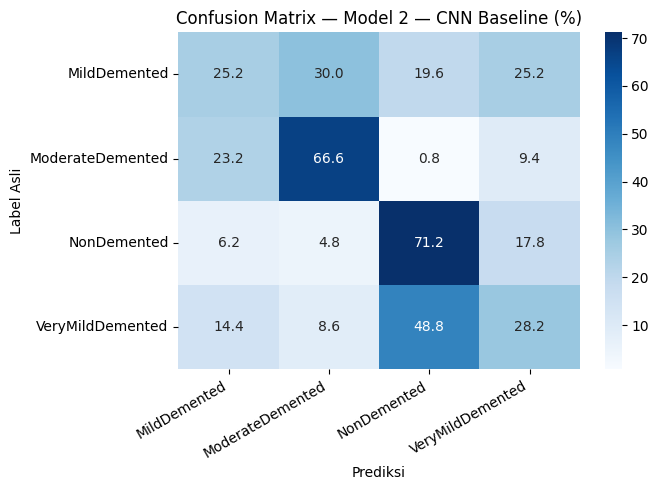

In [ ]:
test_gen.reset()
y_true_cnn = test_gen.classes
y_pred_cnn = np.argmax(cnn_model.predict(test_gen, verbose=0), axis=1)

acc_cnn = accuracy_score(y_true_cnn, y_pred_cnn)
f1_cnn  = f1_score(y_true_cnn, y_pred_cnn, average='weighted')
print('Model 2 — CNN Baseline')
print(f'Accuracy : {acc_cnn*100:.2f}%')
print(f'F1-Score : {f1_cnn:.4f}\n')
print(classification_report(y_true_cnn, y_pred_cnn, target_names=CLASSES))
plot_cm(y_true_cnn, y_pred_cnn, 'Model 2 — CNN Baseline')


---
## Model 3 — ResNet50 Transfer Learning (Deep Learning)
### Bangun Model ResNet50


In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False,
                      input_shape=(*IMG_SIZE, 3))

# Fine-tune 30 layer terakhir
for layer in base_model.layers[:-30]:
    layer.trainable = False

x   = base_model.output
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(256, activation='relu',
                   kernel_regularizer=regularizers.l2(1e-4))(x)
x   = layers.Dropout(0.4)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

resnet_model = models.Model(base_model.input, out, name='ResNet50_TL')
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable = sum(1 for l in resnet_model.layers if l.trainable)
print(f'Total layer   : {len(resnet_model.layers)}')
print(f'Layer dilatih : {trainable}')


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total layer   : 179
Layer dilatih : 34


### Training ResNet50


Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 66s 406ms/step - accuracy: 0.3041 - loss: 1.4586 - val_accuracy: 0.3100 - val_loss: 1.4172 - learning_rate: 1.0000e-04
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 28s 264ms/step - accuracy: 0.3300 - loss: 1.3967 - val_accuracy: 0.3433 - val_loss: 1.3655 - learning_rate: 1.0000e-04
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 254ms/step - accuracy: 0.3541 - loss: 1.3382 - val_accuracy: 0.2700 - val_loss: 1.4733 - learning_rate: 1.0000e-04
Epoch 4/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 254ms/step - accuracy: 0.3794 - loss: 1.3110 - val_accuracy: 0.2533 - val_loss: 2.3651 - learning_rate: 1.0000e-04
Epoch 5/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 253ms/step - accuracy: 0.3994 - loss: 1.2967 - val_accuracy: 0.2867 - val_loss: 1.4798 - learning_rate: 1.0000e-04
Epoch 6/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 255ms/step - accuracy: 0.3824 - loss: 1.3173 - val_accuracy: 0.3967 - val_loss: 1.3274 - learning_rate: 1.0000e-04
Epoch 7/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 28s 26

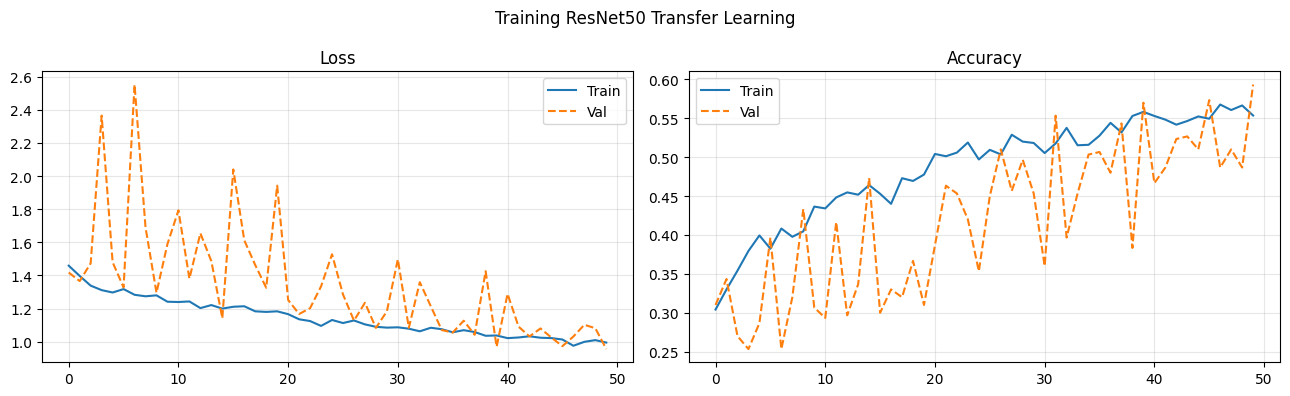

In [ ]:
cbs_tl = [
    EarlyStopping(monitor='val_accuracy', patience=12,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5,
                      patience=6, min_lr=1e-6, verbose=1)
]
history_tl = resnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_TL,
    class_weight=CLASS_WEIGHT,
    callbacks=cbs_tl,
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Training ResNet50 Transfer Learning')
axes[0].plot(history_tl.history['loss'],     label='Train')
axes[0].plot(history_tl.history['val_loss'], label='Val', linestyle='--')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history_tl.history['accuracy'],     label='Train')
axes[1].plot(history_tl.history['val_accuracy'], label='Val', linestyle='--')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'history_resnet.png'), dpi=150)
plt.show()


### Evaluasi ResNet50


Model 3 — ResNet50 Transfer Learning
Accuracy : 61.10%
F1-Score : 0.5938

                  precision    recall  f1-score   support

    MildDemented       0.62      0.43      0.51       500
ModerateDemented       0.76      0.97      0.85       500
     NonDemented       0.56      0.68      0.62       500
VeryMildDemented       0.44      0.36      0.40       500

        accuracy                           0.61      2000
       macro avg       0.60      0.61      0.59      2000
    weighted avg       0.60      0.61      0.59      2000



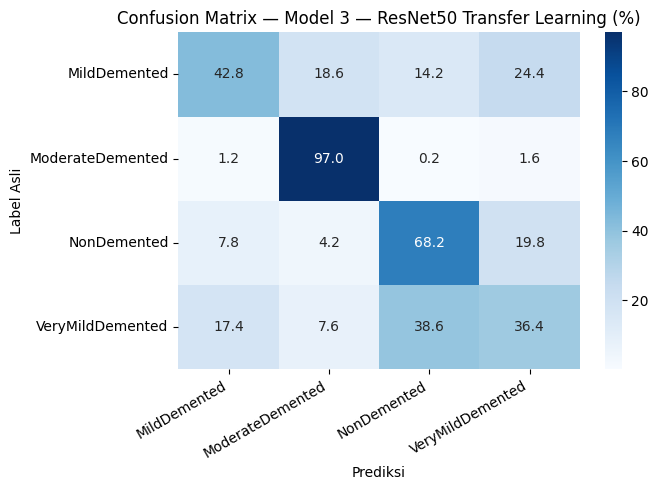

In [ ]:
test_gen.reset()
y_true_tl = test_gen.classes
y_pred_tl = np.argmax(resnet_model.predict(test_gen, verbose=0), axis=1)

acc_tl = accuracy_score(y_true_tl, y_pred_tl)
f1_tl  = f1_score(y_true_tl, y_pred_tl, average='weighted')
print('Model 3 — ResNet50 Transfer Learning')
print(f'Accuracy : {acc_tl*100:.2f}%')
print(f'F1-Score : {f1_tl:.4f}\n')
print(classification_report(y_true_tl, y_pred_tl, target_names=CLASSES))
plot_cm(y_true_tl, y_pred_tl, 'Model 3 — ResNet50 Transfer Learning')


---
## Model 4 — Hybrid CNN + Gabor + HOG + SVM (Kombinasi)

### Mengapa Gabor + HOG untuk Hybrid?

Dua deskriptor ini saling melengkapi:

| Deskriptor | Menangkap | Relevansi MRI |
|---|---|---|
| **Gabor Filter** | Tekstur frekuensial & orientasional (pola periodik) | Sulci, gyri, perubahan jaringan bersifat periodik |
| **HOG** | Gradien lokal & distribusi tepi (struktur bentuk) | Batas antar-jaringan, atrofi kortikal, perubahan struktur |

HOG menerima input **RGB langsung** (`channel_axis=-1`) — tidak perlu konversi grayscale manual.

**Pipeline:**
```
Citra MRI → Morfologi → ┬─ Gabor (OpenCV) → tekstur frekuensial (16-dim)  ─┐
                        ├─ HOG            → gradien/tepi       (1764-dim) ─┤→ Concat → SVM
                        └─ CNN (ResNet50) → fitur semantik     (256-dim)  ─┘
```


### Visualisasi Gabor Filter pada MRI


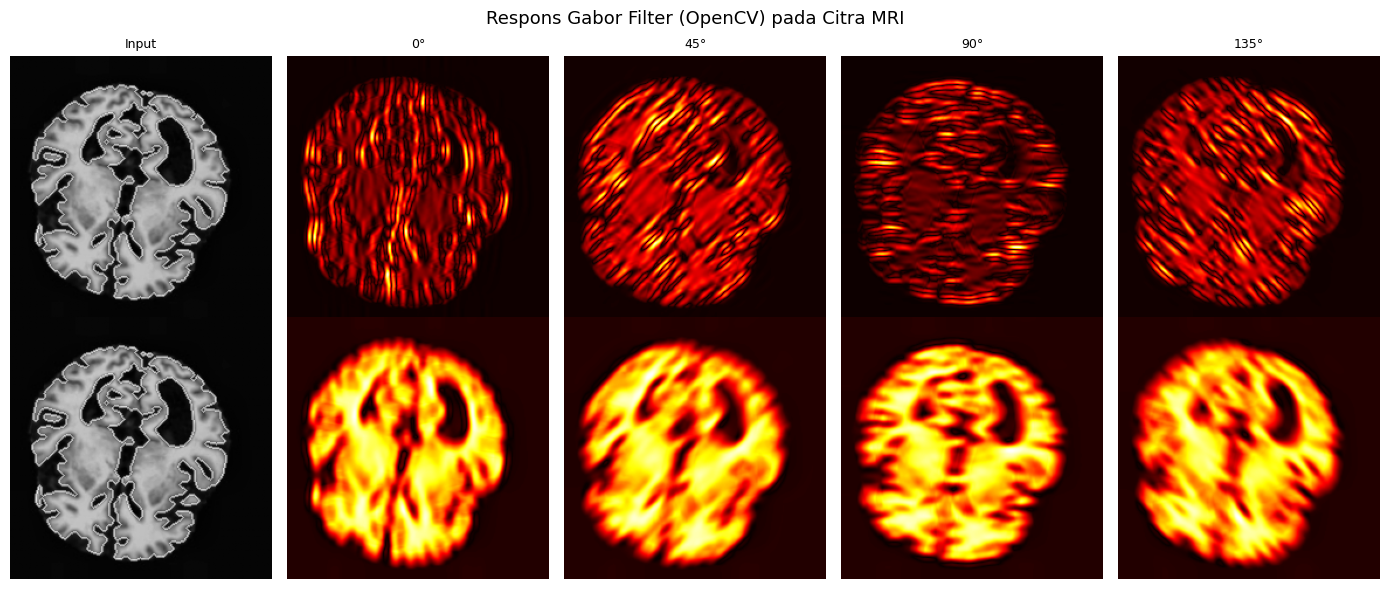

Dimensi fitur Gabor per gambar: 16
Dimensi fitur HOG per gambar: 6084


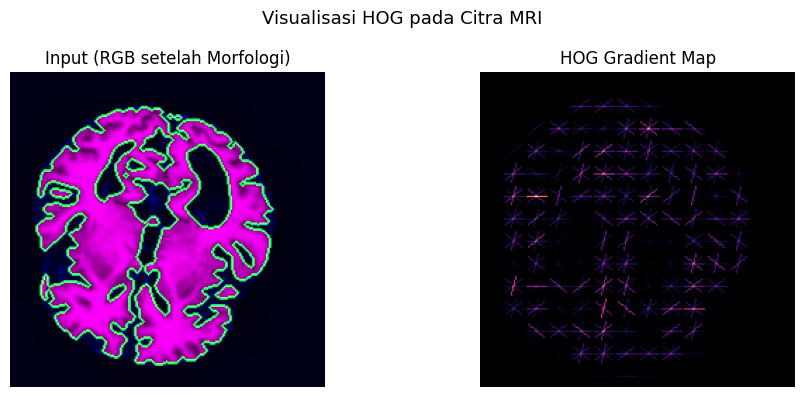

In [ ]:
#Fast Gabor dengan OpenCV
def build_gabor_bank_cv2():
    ksize   = 15
    sigma   = 4.0
    lambdas = [8, 16]   # λ=8px (~freq 0.125), λ=16px (~freq 0.0625)
    thetas  = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    gamma, psi = 0.5, 0
    kernels = []
    for lam in lambdas:
        for theta in thetas:
            k = cv2.getGaborKernel((ksize, ksize), sigma, theta, lam, gamma, psi, ktype=cv2.CV_32F)
            kernels.append((k, lam, theta))
    return kernels

GABOR_BANK = build_gabor_bank_cv2()

def extract_gabor_features(img_array):
    """
    Ekstrak fitur Gabor cepat dengan OpenCV.
    Input : img_array float32 (H, W, 3), nilai [0,1]
    Output: 8 filter × 2 stat = 16-dim
    """
    gray = (np.mean(img_array, axis=2) * 255).astype(np.uint8)
    feature_vec = []
    for (kernel, _, _) in GABOR_BANK:
        filtered  = cv2.filter2D(gray, cv2.CV_32F, kernel)
        magnitude = np.abs(filtered)
        feature_vec.append(magnitude.mean())
        feature_vec.append(magnitude.std())
    return np.array(feature_vec, dtype=np.float32)  # 16-dim


#Visualisasi respons Gabor
sample_path_g  = os.path.join(DATASET_DIR, 'train', CLASSES[0],
                              os.listdir(os.path.join(DATASET_DIR, 'train', CLASSES[0]))[0])
sample_img_g   = cv2.resize(cv2.imread(sample_path_g), IMG_SIZE_SVM)
sample_morph_g = apply_morphology(sample_img_g).astype(np.float32) / 255.0
sample_gray_g  = (np.mean(sample_morph_g, axis=2) * 255).astype(np.uint8)

lambdas_vis  = [8, 16]
thetas_vis   = [0, np.pi/4, np.pi/2, 3*np.pi/4]
theta_labels = ['0°', '45°', '90°', '135°']

fig, axes = plt.subplots(len(lambdas_vis), len(thetas_vis) + 1, figsize=(14, 6))
fig.suptitle('Respons Gabor Filter (OpenCV) pada Citra MRI', fontsize=13)
for i, lam in enumerate(lambdas_vis):
    axes[i, 0].imshow(sample_gray_g, cmap='gray')
    axes[i, 0].set_ylabel(f'λ={lam}px', fontsize=9)
    axes[i, 0].set_title('Input' if i == 0 else '', fontsize=9)
    axes[i, 0].axis('off')
    for j, theta in enumerate(thetas_vis):
        k    = cv2.getGaborKernel((15, 15), 4.0, theta, lam, 0.5, 0, ktype=cv2.CV_32F)
        resp = np.abs(cv2.filter2D(sample_gray_g, cv2.CV_32F, k))
        axes[i, j+1].imshow(resp, cmap='hot')
        axes[i, j+1].set_title(theta_labels[j] if i == 0 else '', fontsize=9)
        axes[i, j+1].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'visualisasi_gabor.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Dimensi fitur Gabor per gambar: {extract_gabor_features(sample_morph_g).shape[0]}')


#HOG Feature Extractor
HOG_ORIENTATIONS  = 9
HOG_PIXELS_CELL   = (16, 16)
HOG_CELLS_BLOCK   = (2, 2)

def extract_hog_features(img_array):
    feat = hog(
        img_array,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_CELL,
        cells_per_block=HOG_CELLS_BLOCK,
        channel_axis=-1,
        feature_vector=True
    )
    return feat.astype(np.float32)

#Cek dimensi HOG sekali
_sample_hog = extract_hog_features(sample_morph_g)
HOG_DIM = _sample_hog.shape[0]
print(f'Dimensi fitur HOG per gambar: {HOG_DIM}')

#Visualisasi HOG pada sampel MRI
from skimage.feature import hog as hog_vis
from skimage import exposure

_, hog_image = hog_vis(
    sample_morph_g,
    orientations=HOG_ORIENTATIONS,
    pixels_per_cell=HOG_PIXELS_CELL,
    cells_per_block=HOG_CELLS_BLOCK,
    channel_axis=-1,
    visualize=True
)
hog_image_resc = exposure.rescale_intensity(hog_image, in_range=(0, 10))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Visualisasi HOG pada Citra MRI', fontsize=13)
axes[0].imshow(sample_morph_g)
axes[0].set_title('Input (RGB setelah Morfologi)'); axes[0].axis('off')
axes[1].imshow(hog_image_resc, cmap='magma')
axes[1].set_title('HOG Gradient Map'); axes[1].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'visualisasi_hog.png'), dpi=150, bbox_inches='tight')
plt.show()


### Bangun CNN untuk Feature Extraction


In [ ]:
#Gunakan ResNet50 sebagai feature extractor untuk Hybrid
base_fe = ResNet50(weights='imagenet', include_top=False,
                   input_shape=(*IMG_SIZE_SVM, 3))
# Freeze semua layer, pakai sebagai fixed feature extractor
for layer in base_fe.layers:
    layer.trainable = False

x_fe       = base_fe.output
x_fe       = layers.GlobalAveragePooling2D()(x_fe)
feat_layer = layers.Dense(256, activation='relu', name='feature_layer')(x_fe)
out_fe     = layers.Dense(NUM_CLASSES, activation='softmax')(feat_layer)

cnn_pretrain      = models.Model(base_fe.input, out_fe,     name='ResNet50_FE_Pretrain')
feature_extractor = models.Model(base_fe.input, feat_layer, name='ResNet50_FE')

cnn_pretrain.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
trainable_fe = sum(1 for l in cnn_pretrain.layers if l.trainable)
print(f'Feature extractor: ResNet50 (frozen) + Dense head')
print(f'Layer dilatih     : {trainable_fe} (hanya Dense head)')
print(f'Input shape       : {IMG_SIZE_SVM}')


Feature extractor: ResNet50 (frozen) + Dense head
Layer dilatih     : 3 (hanya Dense head)
Input shape       : (224, 224)


### Pre-train CNN


Found 1700 images belonging to 4 classes.
Found 300 images belonging to 4 classes.
Pre-training Dense head ResNet50 Feature Extractor...
Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 48s 355ms/step - accuracy: 0.2394 - loss: 1.4530 - val_accuracy: 0.2500 - val_loss: 1.4143 - learning_rate: 1.0000e-04
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 255ms/step - accuracy: 0.2647 - loss: 1.3912 - val_accuracy: 0.2967 - val_loss: 1.3791 - learning_rate: 1.0000e-04
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 252ms/step - accuracy: 0.2888 - loss: 1.3845 - val_accuracy: 0.3067 - val_loss: 1.3807 - learning_rate: 1.0000e-04
Epoch 4/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 254ms/step - accuracy: 0.2876 - loss: 1.3753 - val_accuracy: 0.2867 - val_loss: 1.3706 - learning_rate: 1.0000e-04
Epoch 5/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 28s 266ms/step - accuracy: 0.2906 - loss: 1.3721 - val_accuracy: 0.2767 - val_loss: 1.3896 - learning_rate: 1.0000e-04
Epoch 6/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 250ms/step - accuracy: 0

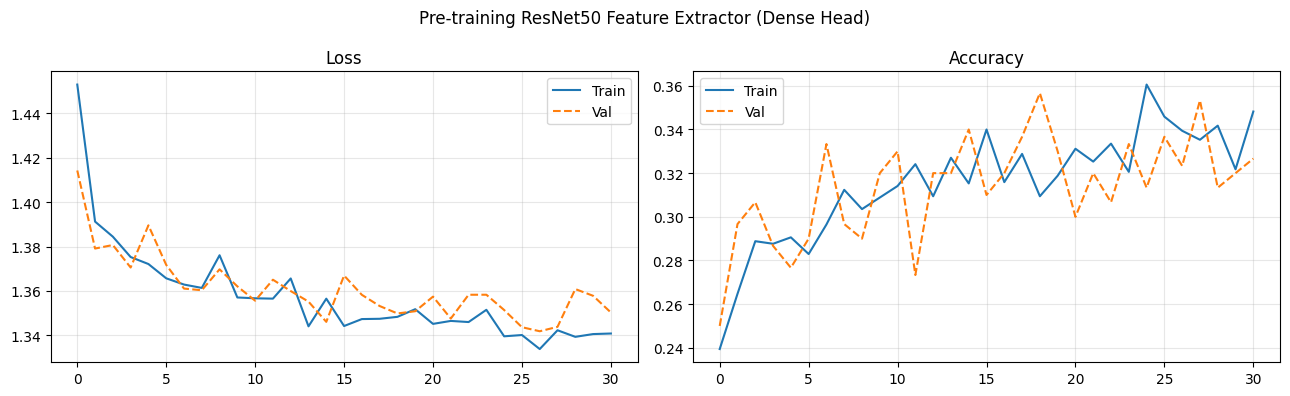

In [ ]:
# Buat generator untuk fine-tune Dense head ResNet50 Feature Extractor
aug_svm = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.15
)
kw_svm = dict(target_size=IMG_SIZE_SVM, batch_size=BATCH_SIZE,
              class_mode='categorical', classes=CLASSES, seed=SEED)

train_gen_svm = aug_svm.flow_from_directory(os.path.join(GEN_DIR, 'train'),
                                            subset='training',   **kw_svm)
val_gen_svm   = aug_svm.flow_from_directory(os.path.join(GEN_DIR, 'train'),
                                            subset='validation', **kw_svm)

cbs_pre = [
    EarlyStopping(monitor='val_accuracy', patience=12,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5,
                      patience=6, min_lr=1e-6, verbose=1)
]

#Hanya melatih Dense head
print('Pre-training Dense head ResNet50 Feature Extractor...')
history_pre = cnn_pretrain.fit(
    train_gen_svm, validation_data=val_gen_svm,
    epochs=EPOCHS_PRE,
    class_weight=CLASS_WEIGHT,
    callbacks=cbs_pre,
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Pre-training ResNet50 Feature Extractor (Dense Head)')
axes[0].plot(history_pre.history['loss'],     label='Train')
axes[0].plot(history_pre.history['val_loss'], label='Val', linestyle='--')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history_pre.history['accuracy'],     label='Train')
axes[1].plot(history_pre.history['val_accuracy'], label='Val', linestyle='--')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'history_pretrain.png'), dpi=150)
plt.show()


### Ekstraksi Fitur: CNN + Gabor → Concat


In [ ]:
def extract_combined_features(X_array, batch_size=64):
    print('  Mengekstrak fitur CNN (ResNet50)...')
    feats_cnn   = feature_extractor.predict(X_array, batch_size=batch_size, verbose=1)

    print('  Mengekstrak fitur Gabor (OpenCV)...')
    feats_gabor = np.array([extract_gabor_features(img) for img in X_array],
                            dtype=np.float32)

    print('  Mengekstrak fitur HOG...')
    feats_hog   = np.array([extract_hog_features(img)   for img in X_array],
                            dtype=np.float32)

    combined = np.concatenate([feats_cnn, feats_gabor, feats_hog], axis=1)
    print(f'\n  Shape CNN   : {feats_cnn.shape}    (semantik)')
    print(f'  Shape Gabor : {feats_gabor.shape}   (tekstur frekuensial)')
    print(f'  Shape HOG   : {feats_hog.shape}  (gradien & tepi)')
    print(f'  Shape Gabung: {combined.shape}  (total fitur hybrid)')
    return combined


print('Mengekstrak fitur CNN + Gabor + HOG — TRAIN...')
feats_train = extract_combined_features(X_train)

print('\nMengekstrak fitur CNN + Gabor + HOG — TEST...')
feats_test  = extract_combined_features(X_test)

scaler             = StandardScaler()
feats_train_scaled = scaler.fit_transform(feats_train)
feats_test_scaled  = scaler.transform(feats_test)
print('\nNormalisasi selesai. Siap latih SVM.')


Mengekstrak fitur CNN + Gabor + HOG — TRAIN...
  Mengekstrak fitur CNN (ResNet50)...
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 308ms/step
  Mengekstrak fitur Gabor (OpenCV)...
  Mengekstrak fitur HOG...

  Shape CNN   : (2000, 256)    (semantik)
  Shape Gabor : (2000, 16)   (tekstur frekuensial)
  Shape HOG   : (2000, 6084)  (gradien & tepi)
  Shape Gabung: (2000, 6356)  (total fitur hybrid)

Mengekstrak fitur CNN + Gabor + HOG — TEST...
  Mengekstrak fitur CNN (ResNet50)...
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 176ms/step
  Mengekstrak fitur Gabor (OpenCV)...
  Mengekstrak fitur HOG...

  Shape CNN   : (2000, 256)    (semantik)
  Shape Gabor : (2000, 16)   (tekstur frekuensial)
  Shape HOG   : (2000, 6084)  (gradien & tepi)
  Shape Gabung: (2000, 6356)  (total fitur hybrid)

Normalisasi selesai. Siap latih SVM.


### Latih SVM


In [ ]:
print('Melatih SVM dengan kernel RBF...')
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=SEED)
svm.fit(feats_train_scaled, y_train)
print('SVM selesai dilatih!')

Melatih SVM dengan kernel RBF...
SVM selesai dilatih!


### Evaluasi Model 4 — Hybrid CNN + Gabor + SVM


Model 4 — Hybrid CNN + Gabor + HOG + SVM
Accuracy : 70.80%
F1-Score : 0.7005

                  precision    recall  f1-score   support

    MildDemented       0.65      0.71      0.68       500
ModerateDemented       0.81      0.97      0.89       500
     NonDemented       0.71      0.62      0.67       500
VeryMildDemented       0.63      0.53      0.58       500

        accuracy                           0.71      2000
       macro avg       0.70      0.71      0.70      2000
    weighted avg       0.70      0.71      0.70      2000



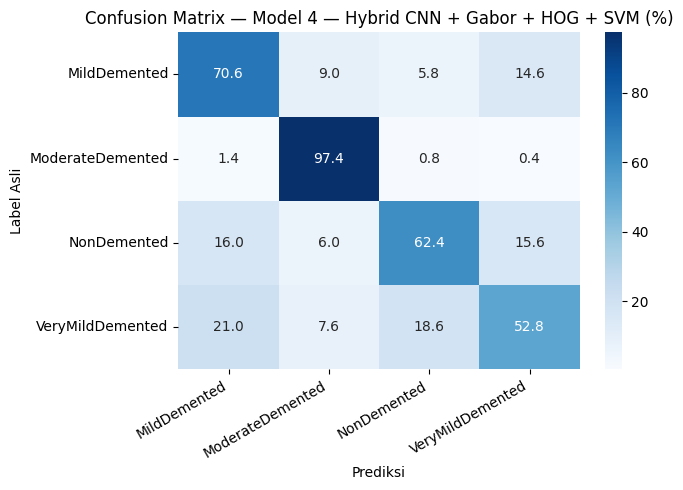

In [ ]:
y_pred_hybrid = svm.predict(feats_test_scaled)
acc_hybrid    = accuracy_score(y_test, y_pred_hybrid)
f1_hybrid     = f1_score(y_test, y_pred_hybrid, average='weighted')

print('Model 4 — Hybrid CNN + Gabor + HOG + SVM')
print(f'Accuracy : {acc_hybrid*100:.2f}%')
print(f'F1-Score : {f1_hybrid:.4f}\n')
print(classification_report(y_test, y_pred_hybrid, target_names=CLASSES))
plot_cm(y_test, y_pred_hybrid, 'Model 4 — Hybrid CNN + Gabor + HOG + SVM')


---
## Perbandingan Semua Model


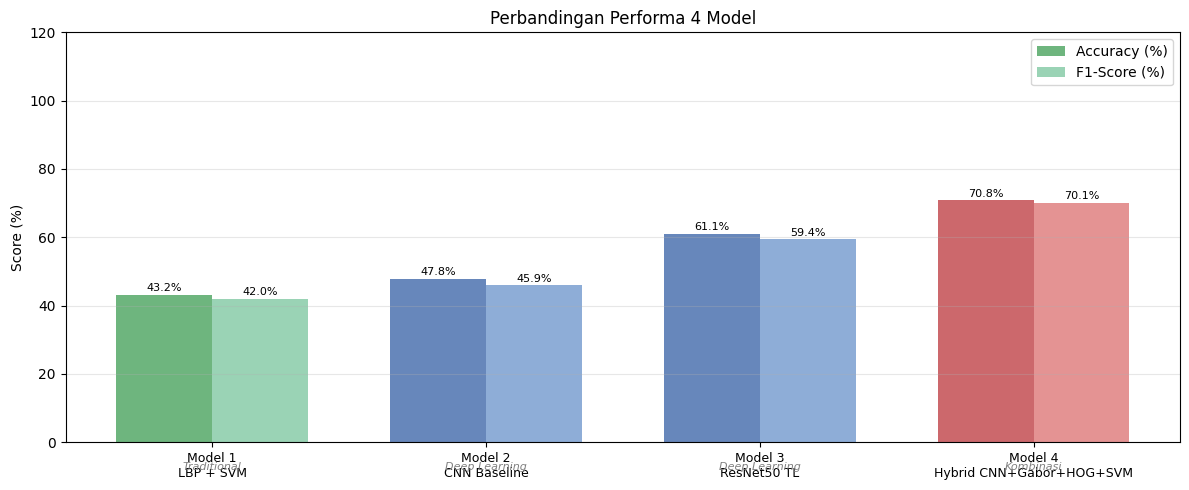


  Model                               Kategori         Accuracy  F1-Score
  ---------------------------------------------------------------
  Model 1 LBP + SVM                   Traditional        43.25%    0.4198
  Model 2 CNN Baseline                Deep Learning      47.80%    0.4593
  Model 3 ResNet50 TL                 Deep Learning      61.10%    0.5938
  Model 4 Hybrid CNN+Gabor+HOG+SVM    Kombinasi          70.80%    0.7005


In [ ]:
model_names = [
    'Model 1\nLBP + SVM',
    'Model 2\nCNN Baseline',
    'Model 3\nResNet50 TL',
    'Model 4\nHybrid CNN+Gabor+HOG+SVM'
]
colors_acc  = ['#55A868', '#4C72B0', '#4C72B0', '#C44E52']
colors_f1   = ['#88CCA8', '#7A9FD0', '#7A9FD0', '#E08080']
accuracies  = [acc_lbp * 100, acc_cnn * 100, acc_tl * 100, acc_hybrid * 100]
f1_scores   = [f1_lbp  * 100, f1_cnn  * 100, f1_tl  * 100, f1_hybrid  * 100]

x = np.arange(len(model_names))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, accuracies, w, label='Accuracy (%)', color=colors_acc, alpha=0.85)
b2 = ax.bar(x + w/2, f1_scores,  w, label='F1-Score (%)', color=colors_f1,  alpha=0.85)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=0, fontsize=9)
ax.set_ylim(0, 120)
ax.set_ylabel('Score (%)')
ax.set_title('Perbandingan Performa 4 Model')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Label kategori di bawah bar
for i, cat in enumerate(categories):
    ax.text(i, -8, cat, ha='center', fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'perbandingan_model.png'), dpi=150)
plt.show()

print('\n' + '='*65)
print(f"  {'Model':<35} {'Kategori':<15} {'Accuracy':>9} {'F1-Score':>9}")
print('  ' + '-'*63)
rows = zip(model_names, categories, accuracies, f1_scores)
for name, cat, acc, f1 in rows:
    name_clean = name.replace('\n', ' ')
    print(f'  {name_clean:<35} {cat:<15} {acc:>8.2f}% {f1/100:>9.4f}')
print('='*65)


## Analisis Perbandingan

Model 1 LBP+SVM memperoleh akurasi terendah sebesar 43.25% karena hanya mengandalkan fitur tekstur lokal tanpa fitur semantik.

Model 2 CNN Baseline (47.80%) dan Model 3 ResNet50 Transfer Learning (61.10%) menunjukkan peningkatan bertahap, di mana ResNet50 unggul berkat bobot pretrained ImageNet.

Model 4 Hybrid CNN+Gabor+HOG+SVM mencapai akurasi tertinggi 70.80%, membuktikan bahwa kombinasi fitur traditional dan deep learning menghasilkan representasi paling komprehensif untuk klasifikasi MRI Alzheimer.